# The link

One port, sessions through the broker: who owns the wire, who else is on it, what a close undoes.

## 1 Setup

In [ ]:
from coaxial import ExecutionMode

MODE = ExecutionMode.EMULATED   # the image on Renode, the stand-in where none runs; .HARDWARE and PORT at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, execution_mode=MODE).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


## 2 Where this session landed

`origin`: the path taken (`debug probe`, `RS485`, `simulated`), asked for or fallen back to. `broker.serving()` reads the address file; `broker.clients()` connects: None with nothing serving, within `CONNECT_S` (a loopback SYN is dropped here: `broker.CONNECT_S`'s comment).

In [3]:
import time

from coaxial.comm import broker

origin = device.origin
print('interface %-10s label %-32s real %-5s unit %d'
      % (origin.interface, origin.label, origin.real, origin.unit))
print('description:', device.system.version()['description'])
print('opened on %r at %d baud; link: %s' % (device.port, device.baud, type(device.link).__name__))
serving = broker.serving()
print('serving:', serving)
t = time.perf_counter()
others = broker.clients()
asked_s = time.perf_counter() - t
print('clients: %s, answered in %.2f s (connect timeout %.1f s)'
      % (others, asked_s, broker.CONNECT_S))

interface simulated  label Simulated                        real False unit 1
description: SIMULATED three-phase BLDC inverter at the pelvis
opened on 'COM4' at 115200 baud; link: SimulatedLink
serving: None


clients: None, answered in 1.01 s (connect timeout 1.0 s)


## 3 The wire's own counters

USART3 on the probe, USART2 and UART5 on RS485. `t15/t35_ticks` in raw CYCCNT (invariant 2); `for_others` = `bus_message` - `server_message`. `loopback`: four patterns back through RE-to-GND transceivers; the link's own port refuses.

In [4]:
from coaxial.errors import DeviceStateError

link = device.link
ports = {port: link.state(port) for port in (0, 1, 2)}
for port, stat in ports.items():
    print('%d %-7s rs485=%-5s open=%-5s %6d baud  t15 %5d  t35 %5d ticks'
          % (port, stat['name'], stat['rs485'], stat['open'], stat['baud'],
             stat['t15_ticks'], stat['t35_ticks']))
    print('  frames seen %d, for this unit %d, for others %d; comm errors %d, '
          'exceptions %d, overruns %d, dropped %d'
          % (stat['bus_message'], stat['server_message'], stat['for_others'],
             stat['bus_comm_error'], stat['server_exception'],
             stat['char_overrun'], stat['ring_dropped']))
gaps = ports[0]['t35_ticks'] / ports[0]['t15_ticks']
print('t35/t15 = %.3f, where 3.5/1.5 = %.3f' % (gaps, 3.5 / 1.5))

0 USART3  rs485=False open=True  115200 baud  t15  1750  t35  4083 ticks
  frames seen 42, for this unit 42, for others 0; comm errors 0, exceptions 0, overruns 0, dropped 0
1 USART2  rs485=True  open=True  115200 baud  t15  1750  t35  4083 ticks
  frames seen 42, for this unit 42, for others 0; comm errors 0, exceptions 0, overruns 0, dropped 0
2 UART5   rs485=True  open=True  115200 baud  t15  1750  t35  4083 ticks
  frames seen 42, for this unit 42, for others 0; comm errors 0, exceptions 0, overruns 0, dropped 0
t35/t15 = 2.333, where 3.5/1.5 = 2.333


In [5]:
loops, refused_ports = {}, []
for port in (0, 1, 2):
    try:
        loops[port] = link.loopback(port)
        print('%d %-7s matched 0x%02X, %d of 4 returned, ok=%s'
              % (port, loops[port]['name'], loops[port]['matched'],
                 loops[port]['returned'], loops[port]['ok']))
    except DeviceStateError as exc:
        refused_ports.append(port)
        print('%d refused: %s' % (port, exc))
t = time.perf_counter()
for _ in range(100):
    link.echo(b'\x00\xff\x5a\xa5')
echo_ms = 1000 * (time.perf_counter() - t) / 100
print('echo: 100 round trips, %.3f ms each' % echo_ms)

0 refused: port 0 carries this conversation; a port cannot check its own loopback while it is answering on it
1 USART2  matched 0x0F, 4 of 4 returned, ok=True
2 UART5   matched 0x0F, 4 of 4 returned, ok=True
echo: 100 round trips, 0.001 ms each


A board's echo over the probe at 115200: ~15 ms (FINDINGS).

## 4 A reading with the front end off

AFE_ON off: mid-scale and 25.00 C; cooked readings refuse, raw codes answer labelled (invariant 9). The rail is refcounted; `users` names the holders.

In [6]:
print('before:', device.afe.state())
try:
    device.analog.scan()
except DeviceStateError as exc:
    print('refused:', exc)
device.daq.enable()
rail = device.afe.state()
print('after enable:', rail)
scan = device.analog.scan()
print('scan: DC link %d mV, NTC %.2f C, afe_on %s'
      % (scan['dcbus_mv'], scan['ntc_centidegc'] / 100.0, scan['afe_on']))

before: {'on': False, 'pe15': True, 'users': []}
refused: the scan reports the analog front end off, so every channel read mid-scale: ntc_centidegc would be exactly 2500 and dcbus_mv a plausible number that is not a measurement. Call board.afe.on() first.
after enable: {'on': True, 'pe15': False, 'users': ['host']}
scan: DC link 28151 mV, NTC 50.14 C, afe_on True


## 5 A second session on the same port

`second`: another session on the port - the broker's at the bench, its own stand-in here. `close()` disarms what its session armed, else only when nobody is left.

In [7]:
second = Coaxial63100(port=PORT, execution_mode=MODE).open()
print(second)
print('the rail, seen from second:', second.afe.state())
shared = second.afe.is_on()
print('the rail device took is visible from second:', shared)
print('clients:', broker.clients())

<Coaxial63100 Simulated SIMULATED>
the rail, seen from second: {'on': False, 'pe15': True, 'users': []}
the rail device took is visible from second: False


clients: None


In [8]:
device.gates.on(bypass_sto=True, ignore_interlock=True)
armed_here, armed_there = device.gates.armed_here, second.gates.armed_here
print('armed: device armed_here=%s is_on()=%s | second armed_here=%s is_on()=%s'
      % (armed_here, device.gates.is_on(), armed_there, second.gates.is_on()))
second.close()
still_armed = device.gates.is_on()
print('second closed: device is_on()=%s, clients %s' % (still_armed, broker.clients()))
after = device.gates.off()
disarmed = not device.gates.is_on()
print('disarmed here: is_on()=%s, break bypassed=%s' % (not disarmed, after['break_bypassed']))

armed: device armed_here=True is_on()=True | second armed_here=False is_on()=False


second closed: device is_on()=True, clients None
disarmed here: is_on()=False, break bypassed=False


No shared board on the stand-in: the stage check holds at the bench only.

## 6 The broker, on a scripted wire

`broker.serve` takes a transport in place of the UART: a scripted wire, 4 ms replies, its own port and address file. Linger 45 s -> 2 s; keepalive 3 s as at the bench.

In [9]:
import os
import tempfile
import threading

from coaxial import errors
from coaxial.comm import protocol


class Wire:
    """A transport that answers without a UART, as test_broker's does:
    every request stamped, and a count of how many were inside at once."""
    baud = 115200

    def __init__(self, delay=0.004):
        self.delay = delay              # a board's reply time, scripted
        self.calls = []
        self.inside = 0
        self.overlapped = 0

    def request(self, unit, function, payload=b'', exact_payload=None,
                timeout=None, reply_shape=None):
        self.inside += 1
        self.overlapped += self.inside > 1
        try:
            self.calls.append((time.perf_counter(), unit, function, bytes(payload)))
            time.sleep(self.delay)
            if function == 0xED:        # scripted: the board refuses this one
                raise errors.DeviceStateError('the analog front end is off')
            return bytes([unit, function]) + bytes(payload)
        finally:
            self.inside -= 1


ADDRESS = ('127.0.0.1', 8795)         # not 8763: a broker serving the bench is left alone
LINGER = 2.0                          # 45 s at the bench, scaled to fit the page
WHERE = os.path.join(tempfile.gettempdir(), 'coaxial_link_paper.addr')   # not broker.WHERE, the bench's
wire = Wire()
threading.Thread(target=broker.serve, args=('WIRE', 115200, ADDRESS),
                 kwargs={'transport': wire, 'linger': LINGER, 'where': WHERE}, daemon=True).start()
up = time.perf_counter()
while not broker.serving(WHERE):
    time.sleep(0.01)
print('serving after %.3f s:' % (time.perf_counter() - up), broker.serving(WHERE))

serving after 0.017 s: {'serial': 'WIRE', 'pid': 18784, 'kind': 'serial', 'host': '127.0.0.1', 'tcp': 8795}


A look is not a use: a client counts from its first request. `BrokerTransport` raises where nothing serves; `attach` answers None.

In [10]:
t = time.perf_counter()
client_1 = broker.BrokerTransport(ADDRESS)
attach_ms = 1000 * (time.perf_counter() - t)
print('attached in %.1f ms to %r at %d baud' % (attach_ms, client_1.port, client_1.baud))
looked = broker.clients(ADDRESS)
print('clients after a look:', looked)
print('a request crosses:', client_1.request(1, protocol.VERSION, b'\x01').hex(' '))
used = broker.clients(ADDRESS)
print('clients after a use:', used)
client_2 = broker.BrokerTransport(ADDRESS)
client_2.request(2, protocol.VERSION, b'\x02')
both = broker.clients(ADDRESS)
print('clients with two using:', both)

attached in 1.3 ms to 'WIRE' at 115200 baud
clients after a look: 0
a request crosses: 01 41 01
clients after a use: 1
clients with two using: 2


Two clients, 25 requests each, two threads; every reply checked against its asker.

In [11]:
before = len(wire.calls)
wrong = []


def hammer(client, tag):
    for _ in range(25):
        got = client.request(tag, protocol.VERSION, bytes([tag]))
        if got != bytes([tag, protocol.VERSION, tag]):
            wrong.append((tag, got.hex()))


threads = [threading.Thread(target=hammer, args=(client, tag))
           for tag, client in ((1, client_1), (2, client_2))]
t = time.perf_counter()
for thread in threads:
    thread.start()
for thread in threads:
    thread.join()
hammer_s = time.perf_counter() - t
crossed = wire.calls[before:]
print('%d requests over two clients in %.3f s = %.1f ms each; %d wrong; '
      'inside the wire together %d times'
      % (len(crossed), hammer_s, 1000 * hammer_s / len(crossed), len(wrong),
         wire.overlapped))
print('order on the wire:', ''.join(str(unit) for _, unit, _, _ in crossed))
crossed_as = 'no refusal'
try:
    client_1.request(1, 0xED)
except errors.RigError as exc:
    crossed_as = type(exc).__name__
    print('a refusal crossed as %s: %s' % (crossed_as, exc))

50 requests over two clients in 0.222 s = 4.4 ms each; 0 wrong; inside the wire together 0 times
order on the wire: 12121212121212121212121212121212121212121212121212
a refusal crossed as DeviceStateError: the analog front end is off


Deadman 10 s (`BOARD_POWER_HOST_QUIET_MS`); the broker speaks every 3 s while a client is attached: 7 s of silence is two keepalives. Then the linger, and a stale address file.

In [12]:
import json

client_2.close()
one_left = broker.clients(ADDRESS)
print('clients after one closed:', one_left)
quiet_from = time.perf_counter()
heard = len(wire.calls)
QUIET = 7.0                     # two 3 s keepalives, under the 10 s deadman
time.sleep(QUIET)
ticks = [stamp - quiet_from for stamp, unit, function, payload in wire.calls[heard:]
         if function == protocol.VERSION and not payload]
print('%d keepalives in %.0f s of silence, at %s s'
      % (len(ticks), QUIET, ', '.join('%.2f' % s for s in ticks)))
left_at = time.perf_counter()
client_1.close()
probe = broker.attach(ADDRESS, timeout=0.3)
while probe is not None:
    probe.close()
    time.sleep(0.05)
    probe = broker.attach(ADDRESS, timeout=0.3)
down_at = time.perf_counter()
print('nothing answers %.2f s after the last client left; the linger is %.1f s here, 45 s at the bench'
      % (down_at - left_at, LINGER))
print('address file after stand-down:', broker.serving(WHERE))
with open(WHERE, 'w', encoding='utf-8') as handle:     # what a killed broker leaves
    json.dump({'serial': 'WIRE', 'pid': 0, 'host': ADDRESS[0], 'tcp': ADDRESS[1]}, handle)
named = broker.serving(WHERE)
t = time.perf_counter()
stale = broker.attach(ADDRESS, timeout=0.5)
stale_s = time.perf_counter() - t
print('a stale file says %s; attaching answers %s in %.2f s (CONNECT_S %.1f s)'
      % (named, stale, stale_s, broker.CONNECT_S))
os.remove(WHERE)

clients after one closed: 1


2 keepalives in 7 s of silence, at 3.25, 6.30 s


nothing answers 2.03 s after the last client left; the linger is 2.0 s here, 45 s at the bench
address file after stand-down: None


a stale file says {'serial': 'WIRE', 'pid': 0, 'host': '127.0.0.1', 'tcp': 8795}; attaching answers None in 1.01 s (CONNECT_S 1.0 s)


Who was on the wire, and when.

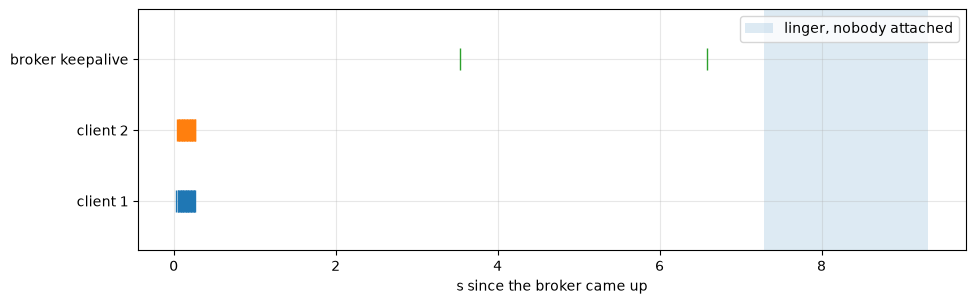

In [13]:
from coaxial.draw.figures import figure, show

fig, (panel,) = figure(rows=1)
lanes = (('client 1', lambda unit, function, payload: payload and unit == 1),
         ('client 2', lambda unit, function, payload: payload and unit == 2),
         ('broker keepalive',
          lambda unit, function, payload: function == protocol.VERSION and not payload))
for lane, (label, mine) in enumerate(lanes):
    stamps = [stamp - up for stamp, unit, function, payload in wire.calls
              if mine(unit, function, payload)]
    panel.plot(stamps, [lane] * len(stamps), '|', markersize=16)
panel.axvspan(left_at - up, down_at - up, alpha=0.15, label='linger, nobody attached')
panel.set_yticks(range(len(lanes)))
panel.set_yticklabels([label for label, _ in lanes])
panel.set_ylim(-0.7, len(lanes) - 0.3)
panel.set_xlabel('s since the broker came up')
panel.legend(loc='upper right')
show(fig)

In [14]:
device.close()
print(device)

<Coaxial63100 Simulated closed SIMULATED>


## 7 Results

In [15]:
print('1. session   %s (%s) on %r; serving %s; clients %s, answered in %.2f s'
      % (origin.interface, origin.label, device.port, serving, others, asked_s))
print('2. wire      t15 %d, t35 %d ticks, t35/t15 %.3f; %d frames seen, %d for this unit, '
      '%d for others, %d comm errors; loopback ok on ports %s, refused on %s; echo %.3f ms a round trip'
      % (ports[0]['t15_ticks'], ports[0]['t35_ticks'], gaps, ports[0]['bus_message'],
         ports[0]['server_message'], ports[0]['for_others'], ports[0]['bus_comm_error'],
         sorted(p for p, loop in loops.items() if loop['ok']), refused_ports, echo_ms))
print('3. front end refused while off; users after enable %s; DC link %d mV, NTC %.2f C once on'
      % (rail['users'], scan['dcbus_mv'], scan['ntc_centidegc'] / 100.0))
print('4. sessions  the rail device took, seen from second: %s; armed here %s, armed_here from second %s; '
      'still armed after second closed %s; disarmed here %s'
      % (shared, armed_here, armed_there, still_armed, disarmed))
print('5. broker    attached in %.1f ms; clients after a look %d, a use %d, two %d, one closed %d; '
      '%d requests %.1f ms each, %d wrong, %d overlapped; a refusal crossed as %s'
      % (attach_ms, looked, used, both, one_left, len(crossed),
         1000 * hammer_s / len(crossed), len(wrong), wire.overlapped, crossed_as))
print('6. timers    %d keepalives in %.0f s of silence at %s s (3 s apart, under the 10 s deadman); '
      'down %.2f s after the last client at a %.1f s linger; a stale file said %s and attaching '
      'answered %s in %.2f s'
      % (len(ticks), QUIET, ', '.join('%.2f' % s for s in ticks), down_at - left_at, LINGER,
         named, stale, stale_s))

1. session   simulated (Simulated) on 'COM4'; serving None; clients None, answered in 1.01 s
2. wire      t15 1750, t35 4083 ticks, t35/t15 2.333; 42 frames seen, 42 for this unit, 0 for others, 0 comm errors; loopback ok on ports [1, 2], refused on [0]; echo 0.001 ms a round trip
3. front end refused while off; users after enable ['host']; DC link 28151 mV, NTC 50.14 C once on
4. sessions  the rail device took, seen from second: False; armed here True, armed_here from second False; still armed after second closed True; disarmed here True
5. broker    attached in 1.3 ms; clients after a look 0, a use 1, two 2, one closed 1; 50 requests 4.4 ms each, 0 wrong, 0 overlapped; a refusal crossed as DeviceStateError
6. timers    2 keepalives in 7 s of silence at 3.25, 6.30 s (3 s apart, under the 10 s deadman); down 2.03 s after the last client at a 2.0 s linger; a stale file said {'serial': 'WIRE', 'pid': 0, 'host': '127.0.0.1', 'tcp': 8795} and attaching answered None in 1.01 s


- `open()` through a live broker 0.05 s, starting one 5.85 s: it lingers 45 s (FINDINGS 2026-08-29).
- One lock: 50 requests crossed whole, alternating, never overlapped.
- A refusal crosses as its own `coaxial.errors` class (invariant 8).
- The stage is the board's: three runs once ended when a second session asked (FINDINGS 2026-08-29).

**Bench.** `python tools/target/session.py --status`: what serves the port, and whether it answers. t35/t15 2.33; comm errors 0 after a minute of traffic.

## References

* `host/coaxial/comm/session.py` - `open_session`: a serving broker first, then the ports, then the stand-in
* `host/coaxial/comm/broker.py` - the broker: one lock, the keepalive, `clients()`, `attach` on `CONNECT_S`
* `host/tools/target/session.py` - the broker `spawn()` starts for a port; `--status` names what serves it
* `host/coaxial/rig.py` - `close()`: what a session disarms, and when
* `comms/src/cmd_link.c` - echo and the counters, per port
* `board/src/board_power.c` - the deadman: a silent host loses its claims after `BOARD_POWER_HOST_QUIET_MS`
* `host/tests/test_broker.py` - the broker pinned on a scripted port, no board